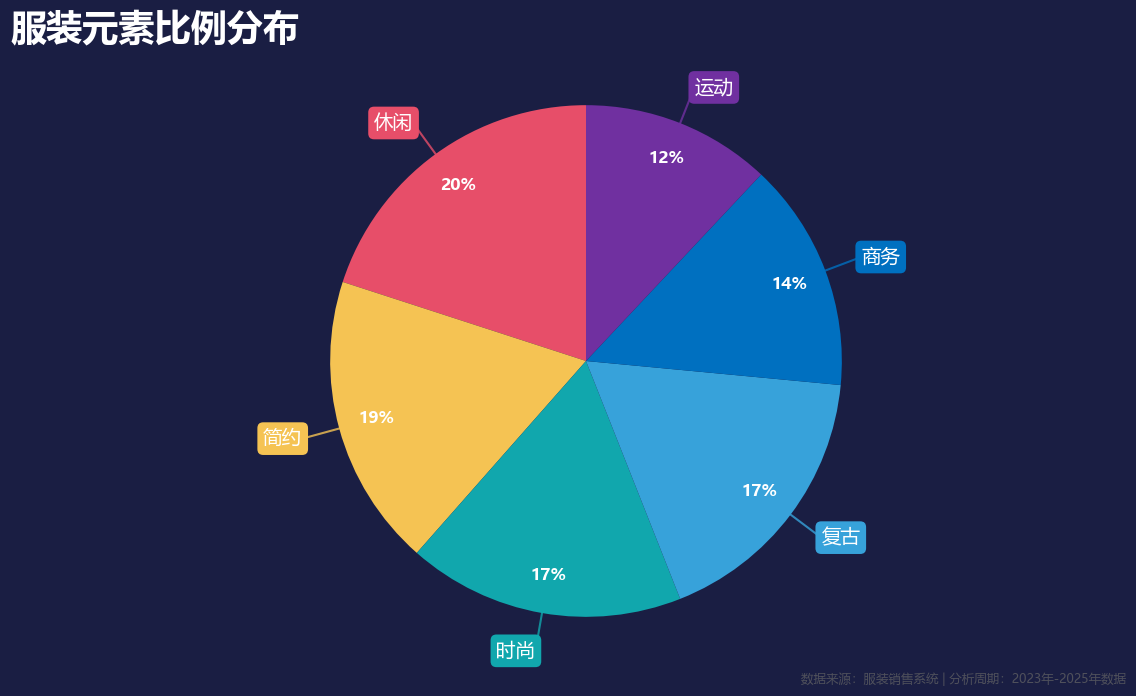

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取数据
    df_spu = pd.read_csv("../../spu_manages_feishu.csv", encoding="utf-8-sig")

    # 提取“元素类型”列并统计频次
    element_counts = df_spu["元素类型"].value_counts().reset_index()
    element_counts.columns = ["元素类型", "数量"]

    # 定义颜色方案
    colors = [
        "#e74e69",  # 粉红
        "#f5c353",  # 金黄
        "#11a7ad",  # 青蓝
        "#37a2da",  # 蓝
        "#0070c0",  # 深蓝
        "#7030a0"   # 紫
    ]

    # 创建画布与子图（深色背景）
    fig, ax = plt.subplots(figsize=(12, 7))
    BACKGROUND_COLOR = "#1A1E43"
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_facecolor(BACKGROUND_COLOR)

    # 绘制饼图
    wedges, texts, autotexts = ax.pie(
        element_counts["数量"],
        labels=None,
        autopct='%1.f%%',
        colors=colors,
        startangle=90,
        pctdistance=0.85,
        textprops={'color': 'white', 'fontsize': 12, 'weight': 'bold'},
        wedgeprops=dict(edgecolor=None, linewidth=2)
    )

    # 设置百分比文本样式
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(12)
        autotext.set_weight('bold')

    # 添加引线（从饼图扇区指向外部标签）
    for i, (wedge, label) in enumerate(zip(wedges, element_counts["元素类型"])):
        angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))

        # 根据x坐标确定水平对齐方式
        horizontalalignment = 'left' if x >= 0 else 'right'
        
        # 更改引导线起点和终点
        x_start = x * 0.85
        y_start = y * 0.85
        x_end = x * 1.15
        y_end = y * 1.15

        # 在饼图外侧添加标签
        ax.text(
            x * 1.15, y * 1.15, label,
            color='white',
            fontsize=14,
            ha=horizontalalignment,
            va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[i], edgecolor='none')
        )

        # 绘制更精准的引导线
        ax.plot(
            [x_start, x_end],
            [y_start, y_end],
            color=colors[i],
            linestyle='-',
            linewidth=1.5,
            alpha=0.8
        )

        # 为垂直方向的标签添加小偏移避免重叠
        if abs(x) < 0.2:  # 接近垂直方向
            offset = 0.05 if y > 0 else -0.05
            ax.plot(
                [x_end, x_end],
                [y_end, y_end + offset],
                color=colors[i],
                linestyle='-',
                linewidth=1.5,
                alpha=0.8
            )

    # 标题设置
    plt.figtext(0.02, 0.95, "服装元素比例分布",
                ha='left', fontsize=26, color='#ffffff', fontweight='bold')
    plt.figtext(0.95, 0.03,
                '数据来源：服装销售系统 | 分析周期：2023年-2025年数据',
                ha='right', fontsize=9, color='#666666', alpha=0.7)

    # 移除坐标轴
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xticks([])
    ax.set_yticks([])

    # 调整布局防止截断
    plt.tight_layout(rect=(0.05, 0.03, 0.95, 0.95))

    # 保存图像
    plt.savefig("服装元素比例分布.png", dpi=300, bbox_inches='tight', facecolor=BACKGROUND_COLOR)

    # 显示图表
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 数据分析

- **休闲**（红色）：
  占比最高，达到20%，表明休闲类服装在市场中的需求较大，可能与消费者对舒适性和日常穿着的需求有关。

- **简约**（黄色）：
  占比19%，紧随其后，显示出简约风格服装也受到市场的广泛欢迎，可能反映了消费者对简洁设计和实用性的偏好。

- **复古**（浅蓝色）：
  占比17%，与时尚类服装持平，表明复古风格服装在市场中有一定的吸引力，可能与消费者对经典和怀旧元素的追求有关。

- **时尚**（青色）：
  同样占比17%，显示出时尚类服装在市场中的重要性，可能与消费者对潮流和个性化表达的需求有关。

- **商务**（深蓝色）：
  占比14%，表明商务类服装在市场中也占有一定份额，可能与职业人士对正式着装的需求有关。

- **运动**（紫色）：
  占比12%，虽然相对较低，但仍然显示出运动类服装在市场中的需求，可能与健康生活方式和运动休闲趋势有关。


# 结论

从服装元素类型的分布来看，休闲和简约风格的服装在市场中占据主导地位，显示出消费者对舒适性和简洁设计的偏好。复古和时尚风格的服装也受到市场的欢迎，表明消费者对个性化和潮流的追求。商务和运动类服装虽然占比相对较低，但仍然显示出一定的市场需求。